In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import os

# === Import your model and dataset classes ===
from identification.models import PhysQuadModel
from quadrotor_sys import quad_dynamics

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['axes.labelsize']=14
plt.rcParams['xtick.labelsize']=11
plt.rcParams['ytick.labelsize']=11
plt.rcParams['axes.grid']=True
plt.rcParams['axes.xmargin']=0
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['legend.fontsize']=11

In [3]:
# === Config ===
onestep = False
learn_params = False
residual = True
horizon = 100
custom_loss = False

dt=0.01

# === Initialize model ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# === Dynamics parameters ===
phys_params = {
    "g": 9.81,
    "m": 0.045,
    "J": np.diag([2.3951e-5, 2.3951e-5, 3.2347e-5]),
    "thrust_to_weight": 2.0,
    "max_torque": np.array([1e-2, 1e-2, 3e-3]),
}

model = PhysQuadModel(phys_params, dt).to(device)

from simulator.utils.solvers import simulate_rollout
from simulator.utils.solvers import step_dynamics_rk4, step_dynamics_dopri5

df = pd.read_csv('../data/debug/figure8-mellinger/mellinger/ctrl_normalized.csv').dropna()
df_phys = pd.read_csv('../data/debug/figure8-mellinger/mellinger/ctrl_physical.csv').dropna()

x0 = np.zeros(13)
x0[9] = 1.0
u = df.values[:,1:]
u_phys = df_phys.values[:,1:]


In [4]:
# Assuming df.t is your time vector
# u: [N,4] normalized inputs from data
# u_norm_torch: [N,4] normalized inputs from model
# u_phys: [N,4] physical inputs

# time = df.t.values  # adjust if your dataframe has different structure

# fig, ax = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
#
# control_labels = ['T', 'M1', 'M2', 'M3']
#
# for i in range(4):
#     ax1 = ax[i]
#     ax1.plot(time, u[:, i], label=f'{control_labels[i]} (u)', color='tab:blue')
#     ax1.set_ylabel(f'{control_labels[i]} (norm)')
#     ax1.legend(loc='upper left')
#     ax1.grid(True)
#
#     # Twin axis for u_phys
#     ax2 = ax1.twinx()
#     ax2.plot(time, u_phys[:, i], label=f'{control_labels[i]} (u_phys)', color='tab:green')
#     ax2.set_ylabel(f'{control_labels[i]} (phys)', color='tab:green')
#     ax2.tick_params(axis='y', labelcolor='tab:green')
#
#     # Combine legends
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
#
# ax[-1].set_xlabel('Time [s]')
# plt.tight_layout()
# plt.show()


In [5]:
# Check CUDA availability
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    print(f"Number of CUDA devices: {num_devices}")

    for i in range(num_devices):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA is not available.")

Number of CUDA devices: 1
Device 0: NVIDIA GeForce RTX 4070 Laptop GPU


In [6]:
from scipy.spatial.transform import Rotation as R

X = simulate_rollout(x0, u, dt, quad_dynamics, phys_params, step_fn=step_dynamics_rk4)[:-1]

pos_jax   = X[:, 0:3]
vel_jax   = X[:, 3:6]
quat_jax  = X[:, 6:10]
omega_jax = X[:, 10:13]

time = np.arange(X.shape[0]) * dt

# Convert JAX quaternions to Euler
r_jax = R.from_quat(quat_jax)   # expects [x,y,z,w]
euler_jax = r_jax.as_euler('xyz', degrees=False)

In [7]:
x_all = []

# x0 must be shape (1,13) and contain [pos, vel, quat, omega]
x = torch.tensor(x0, dtype=torch.float32, device=device).unsqueeze(0)  # (1,13)

for i in range(df.shape[0]):
    # Save current 13-dim state
    x_all.append(x.clone())

    # u_phys from dataframe: [T_norm, τx_norm, τy_norm, τz_norm]
    u_phys = torch.tensor(df.values[i, 1:], dtype=torch.float32, device=device).unsqueeze(0)

    # integrate one step (x stays 13-dimensional)
    x = model._step_from_phys(x, u_phys)

# Stack: shape [N,13]
X_torch = torch.cat(x_all, dim=0).cpu().numpy()


In [8]:
# --- Extract PyTorch rollout ---
# X_torch shape: [N,13]
pos_t   = X_torch[:, 0:3]
vel_t   = X_torch[:, 3:6]
quat_t   = X_torch[:, 6:10]
omega_t = X_torch[:, 10:13]

# Convert PyTorch quats to Euler
r_t = R.from_quat(quat_t)
euler_t = r_t.as_euler('xyz', degrees=False)

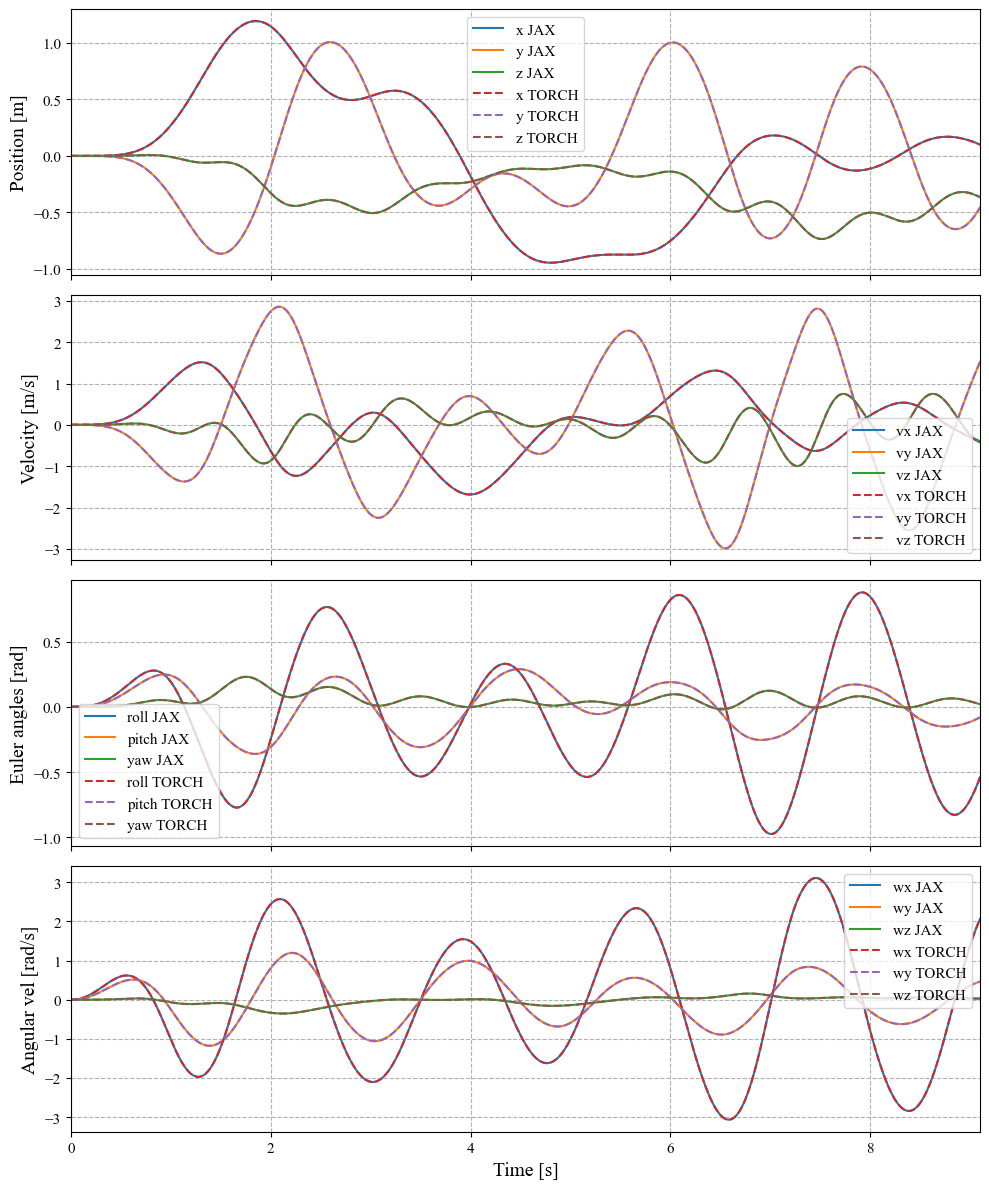

In [9]:
# =============================
# ======== PLOT ============
# =============================
fig, ax = plt.subplots(4, 1, figsize=(10,12), sharex=True)

# Position
ax[0].plot(time, pos_jax[:,0], label='x JAX')
ax[0].plot(time, pos_jax[:,1], label='y JAX')
ax[0].plot(time, pos_jax[:,2], label='z JAX')

ax[0].plot(time, pos_t[:,0], '--', label='x TORCH')
ax[0].plot(time, pos_t[:,1], '--', label='y TORCH')
ax[0].plot(time, pos_t[:,2], '--', label='z TORCH')

ax[0].set_ylabel('Position [m]')
ax[0].legend()
ax[0].grid(True)

# Velocity
ax[1].plot(time, vel_jax[:,0], label='vx JAX')
ax[1].plot(time, vel_jax[:,1], label='vy JAX')
ax[1].plot(time, vel_jax[:,2], label='vz JAX')

ax[1].plot(time, vel_t[:,0], '--', label='vx TORCH')
ax[1].plot(time, vel_t[:,1], '--', label='vy TORCH')
ax[1].plot(time, vel_t[:,2], '--', label='vz TORCH')

ax[1].set_ylabel('Velocity [m/s]')
ax[1].legend()
ax[1].grid(True)

# Euler angles
ax[2].plot(time, euler_jax[:,0], label='roll JAX')
ax[2].plot(time, euler_jax[:,1], label='pitch JAX')
ax[2].plot(time, euler_jax[:,2], label='yaw JAX')

ax[2].plot(time, euler_t[:,0], '--', label='roll TORCH')
ax[2].plot(time, euler_t[:,1], '--', label='pitch TORCH')
ax[2].plot(time, euler_t[:,2], '--', label='yaw TORCH')

ax[2].set_ylabel('Euler angles [rad]')
ax[2].legend()
ax[2].grid(True)

# Angular velocity
ax[3].plot(time, omega_jax[:,0], label='wx JAX')
ax[3].plot(time, omega_jax[:,1], label='wy JAX')
ax[3].plot(time, omega_jax[:,2], label='wz JAX')

ax[3].plot(time, omega_t[:,0], '--', label='wx TORCH')
ax[3].plot(time, omega_t[:,1], '--', label='wy TORCH')
ax[3].plot(time, omega_t[:,2], '--', label='wz TORCH')

ax[3].set_ylabel('Angular vel [rad/s]')
ax[3].set_xlabel('Time [s]')
ax[3].legend()
ax[3].grid(True)

plt.tight_layout()
plt.show()

In [10]:
from pytorch3d.transforms import (
    quaternion_to_axis_angle,
    axis_angle_to_quaternion,
)

def quat_to_so3_log_p3d(q_xyzw):
    q_wxyz = torch.cat([q_xyzw[..., 3:], q_xyzw[..., :3]], dim=-1)
    return quaternion_to_axis_angle(q_wxyz)

def so3_log_to_quat_p3d(r):
    q_wxyz = axis_angle_to_quaternion(r)
    return torch.cat([q_wxyz[..., 1:], q_wxyz[..., :1]], dim=-1)


In [11]:
x_all = []

# x0 = [pos, vel, quat, omega], shape (1,13)
x = torch.tensor(x0, dtype=torch.float32, device=device).unsqueeze(0)  # (1,13)

for i in range(df.shape[0]):

    # 1. Save current quaternion state
    x_all.append(x.clone())    # (1,13)

    # 2. Convert quaternion → axis-angle (SO3 log)
    pos   = x[:, 0:3]
    vel   = x[:, 3:6]
    quat  = x[:, 6:10]        # (x,y,z,w)
    omega = x[:, 10:13]

    so3 = quat_to_so3_log_p3d(quat)   # (1,3)

    # Build 12-dim state for model.one_step
    x_so3 = torch.cat([pos, vel, so3, omega], dim=-1)   # (1,12)

    # 3. Prepare control input
    u_phys = torch.tensor(df.values[i, 1:], dtype=torch.float32, device=device).unsqueeze(0)

    # 4. Integrate one step in SO3-log space
    x_next_so3 = model.one_step(x_so3, u_phys)   # (1,12)

    # 5. Convert back to quaternion representation
    pos_next   = x_next_so3[:, 0:3]
    vel_next   = x_next_so3[:, 3:6]
    so3_next   = x_next_so3[:, 6:9]
    omega_next = x_next_so3[:, 9:12]

    quat_next = so3_log_to_quat_p3d(so3_next)    # (1,4)

    # Build next quaternion state (13-dim)
    x = torch.cat([pos_next, vel_next, quat_next, omega_next], dim=-1)  # (1,13)

# Final stack
X_torch = torch.cat(x_all, dim=0).cpu().numpy()   # [N,13]


In [12]:
# --- Extract PyTorch rollout ---
# X_torch shape: [N,13]
pos_t   = X_torch[:, 0:3]
vel_t   = X_torch[:, 3:6]
quat_t   = X_torch[:, 6:10]
omega_t = X_torch[:, 10:13]

# Convert PyTorch quats to Euler
r_t = R.from_quat(quat_t)
euler_t = r_t.as_euler('xyz', degrees=False)

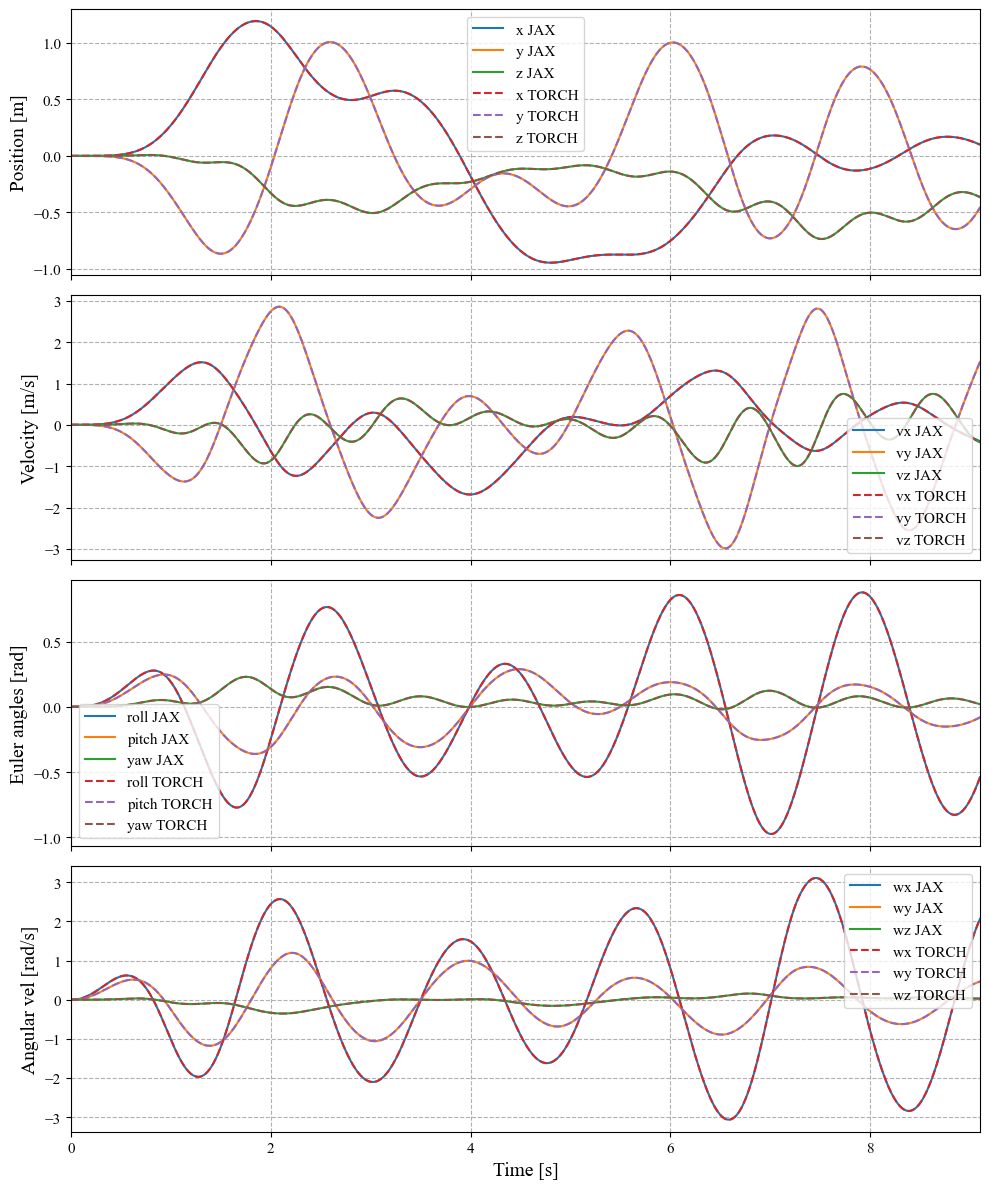

In [13]:
# =============================
# ======== PLOT ============
# =============================
fig, ax = plt.subplots(4, 1, figsize=(10,12), sharex=True)

# Position
ax[0].plot(time, pos_jax[:,0], label='x JAX')
ax[0].plot(time, pos_jax[:,1], label='y JAX')
ax[0].plot(time, pos_jax[:,2], label='z JAX')

ax[0].plot(time, pos_t[:,0], '--', label='x TORCH')
ax[0].plot(time, pos_t[:,1], '--', label='y TORCH')
ax[0].plot(time, pos_t[:,2], '--', label='z TORCH')

ax[0].set_ylabel('Position [m]')
ax[0].legend()
ax[0].grid(True)

# Velocity
ax[1].plot(time, vel_jax[:,0], label='vx JAX')
ax[1].plot(time, vel_jax[:,1], label='vy JAX')
ax[1].plot(time, vel_jax[:,2], label='vz JAX')

ax[1].plot(time, vel_t[:,0], '--', label='vx TORCH')
ax[1].plot(time, vel_t[:,1], '--', label='vy TORCH')
ax[1].plot(time, vel_t[:,2], '--', label='vz TORCH')

ax[1].set_ylabel('Velocity [m/s]')
ax[1].legend()
ax[1].grid(True)

# Euler angles
ax[2].plot(time, euler_jax[:,0], label='roll JAX')
ax[2].plot(time, euler_jax[:,1], label='pitch JAX')
ax[2].plot(time, euler_jax[:,2], label='yaw JAX')

ax[2].plot(time, euler_t[:,0], '--', label='roll TORCH')
ax[2].plot(time, euler_t[:,1], '--', label='pitch TORCH')
ax[2].plot(time, euler_t[:,2], '--', label='yaw TORCH')

ax[2].set_ylabel('Euler angles [rad]')
ax[2].legend()
ax[2].grid(True)

# Angular velocity
ax[3].plot(time, omega_jax[:,0], label='wx JAX')
ax[3].plot(time, omega_jax[:,1], label='wy JAX')
ax[3].plot(time, omega_jax[:,2], label='wz JAX')

ax[3].plot(time, omega_t[:,0], '--', label='wx TORCH')
ax[3].plot(time, omega_t[:,1], '--', label='wy TORCH')
ax[3].plot(time, omega_t[:,2], '--', label='wz TORCH')

ax[3].set_ylabel('Angular vel [rad/s]')
ax[3].set_xlabel('Time [s]')
ax[3].legend()
ax[3].grid(True)

plt.tight_layout()
plt.show()